# Gazetteer Legacy vs DUUI-Py MsgPack/Lua Evaluation

This is the visual, professor-facing report. It compares `gazetteer-legacy-lua` against the modern `gazetteer-msgpack-lua` path on six XMI-derived BioFID-style text chunks.

**Headline:** both measured configs produced exact normalized-span equivalence across all six documents. The latency difference is small in this local in-process run, and DUUI-Py telemetry captured logs, request metrics, spans, summaries, CPU, and memory metrics.

**Important setup note:** the Rust Gazetteer backend responds at `/v1/process`; root `/` returns 404. The measured run therefore pins `GAZETTEER_RS_URL` to `http://127.0.0.1:<port>/v1/process`.


In [1]:
from pathlib import Path
import json
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "DejaVu Sans"

RESULT_PATH = next(path for path in [
    Path("gazetteer_legacy_vs_msgpack_evaluation_results.json"),
    Path("duui-py/examples/gazetteer_legacy_vs_msgpack_evaluation_results.json"),
] if path.exists())

data = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
config_runs = data["config_runs"]

rows = []
pairs = []
events = []
for config_name, run in config_runs.items():
    for row in run["rows"]:
        rows.append({"config": config_name, **row})
    for pair in run["pairs"]:
        pairs.append({"config": config_name, **pair})
    for event in run["telemetry_events"]:
        events.append({"config": config_name, **event})

rows_df = pd.DataFrame(rows)
pairs_df = pd.DataFrame(pairs)
events_df = pd.DataFrame(events)

summary_df = (
    rows_df.groupby(["config", "component"])
    .agg(
        docs=("doc_id", "count"),
        mean_ms=("elapsed_ms", "mean"),
        median_ms=("elapsed_ms", "median"),
        min_ms=("elapsed_ms", "min"),
        max_ms=("elapsed_ms", "max"),
        annotations=("annotation_count", "sum"),
    )
    .reset_index()
)
summary_df[["mean_ms", "median_ms", "min_ms", "max_ms"]] = summary_df[["mean_ms", "median_ms", "min_ms", "max_ms"]].round(2)
summary_df

,config,component,docs,mean_ms,median_ms,min_ms,max_ms,annotations
0,plain-de,legacy,6,2.92,2.83,2.40,3.46,2
1,plain-de,modern,6,3.05,3.02,2.87,3.28,2
2,virus-skipgram,legacy,6,3.14,3.15,2.82,3.42,0
3,virus-skipgram,modern,6,3.47,3.41,2.92,4.21,0


## Latency Summary

Mean warm request latency by config and component. This excludes backend startup/resource loading and focuses on annotator contract/parsing plus backend request time.

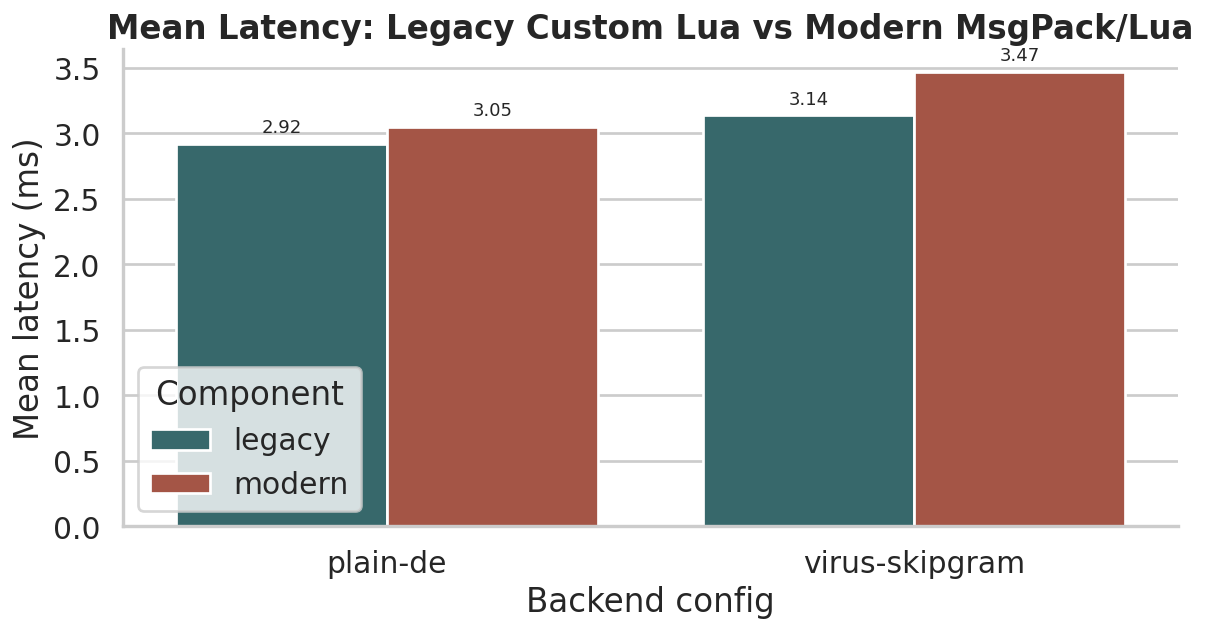

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.barplot(
    data=summary_df,
    x="config",
    y="mean_ms",
    hue="component",
    palette={"legacy": "#2f6f73", "modern": "#b44a36"},
    ax=ax,
)
ax.set_title("Mean Latency: Legacy Custom Lua vs Modern MsgPack/Lua")
ax.set_xlabel("Backend config")
ax.set_ylabel("Mean latency (ms)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=4, fontsize=10)
ax.legend(title="Component", frameon=True)
sns.despine()
plt.tight_layout()

## Per-Document Timing

Same document chunks, paired by component. This is the fastest sanity check for whether one contract path is consistently slower.

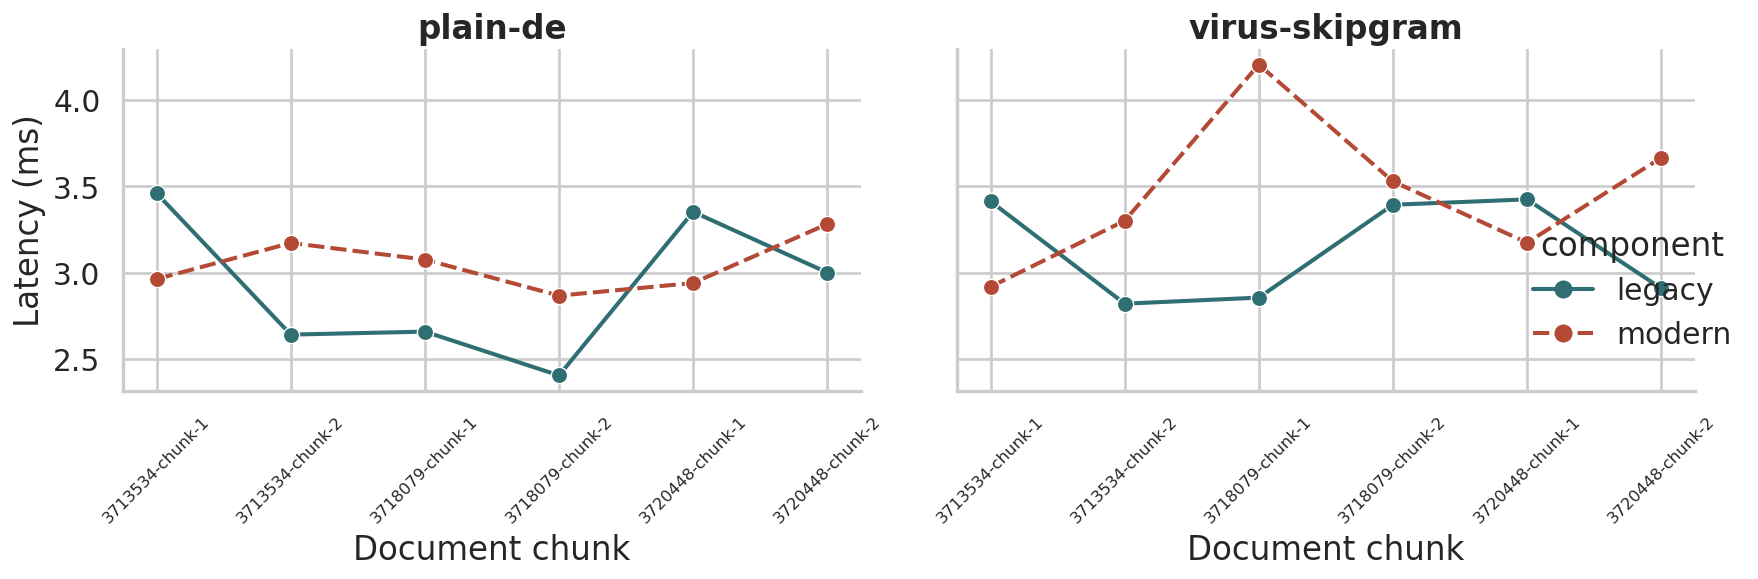

In [3]:
g = sns.relplot(
    data=rows_df,
    x="doc_id",
    y="elapsed_ms",
    hue="component",
    style="component",
    col="config",
    kind="line",
    marker="o",
    height=4.8,
    aspect=1.25,
    palette={"legacy": "#2f6f73", "modern": "#b44a36"},
)
g.set_axis_labels("Document chunk", "Latency (ms)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.set_title(ax.get_title(), fontweight="bold")
plt.tight_layout()

## Functional Equivalence

Equivalence is computed after normalizing both outputs to `(begin, end, value, identifier)`. Legacy returns a JSON list; modern returns UIMA `Taxon` annotations plus metadata. The comparison removes transport/contract shape differences and checks semantic annotation equality.

,config,docs,equivalent_docs,legacy_only,modern_only,intersections,equivalence_rate
0,plain-de,6,6,0,0,2,1.0
1,virus-skipgram,6,6,0,0,0,1.0


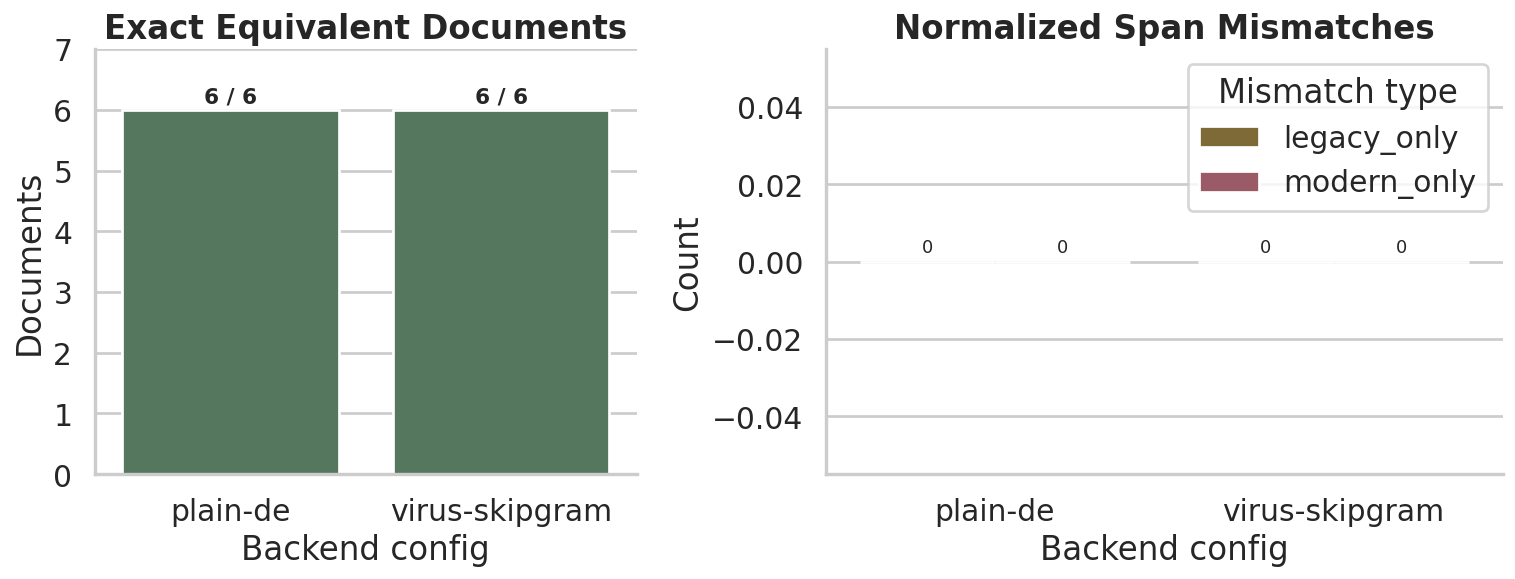

In [4]:
equiv_df = (
    pairs_df.assign(equivalent_int=pairs_df["equivalent"].astype(int))
    .groupby("config")
    .agg(
        docs=("doc_id", "count"),
        equivalent_docs=("equivalent_int", "sum"),
        legacy_only=("legacy_only", "sum"),
        modern_only=("modern_only", "sum"),
        intersections=("intersection", "sum"),
    )
    .reset_index()
)
equiv_df["equivalence_rate"] = equiv_df["equivalent_docs"] / equiv_df["docs"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1, 1.25]})
sns.barplot(data=equiv_df, x="config", y="equivalent_docs", color="#4f7d5a", ax=axes[0])
axes[0].set_title("Exact Equivalent Documents")
axes[0].set_xlabel("Backend config")
axes[0].set_ylabel("Documents")
axes[0].set_ylim(0, max(equiv_df["docs"]) + 1)
for i, row in equiv_df.iterrows():
    axes[0].text(i, row["equivalent_docs"] + 0.12, f'{int(row["equivalent_docs"])} / {int(row["docs"])}', ha="center", fontsize=12, fontweight="bold")

mismatch_df = equiv_df.melt(
    id_vars="config",
    value_vars=["legacy_only", "modern_only"],
    var_name="mismatch_type",
    value_name="count",
)
sns.barplot(data=mismatch_df, x="config", y="count", hue="mismatch_type", palette=["#8a6f2a", "#a54f5f"], ax=axes[1])
axes[1].set_title("Normalized Span Mismatches")
axes[1].set_xlabel("Backend config")
axes[1].set_ylabel("Count")
axes[1].legend(title="Mismatch type")
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, fontsize=10)
sns.despine()
plt.tight_layout()
equiv_df

## Annotation Counts

The `plain-de` resource subset finds German vernacular names in two chunks. The `virus-skipgram` subset is useful as a second config path but does not find virus names in these six botanical chunks.

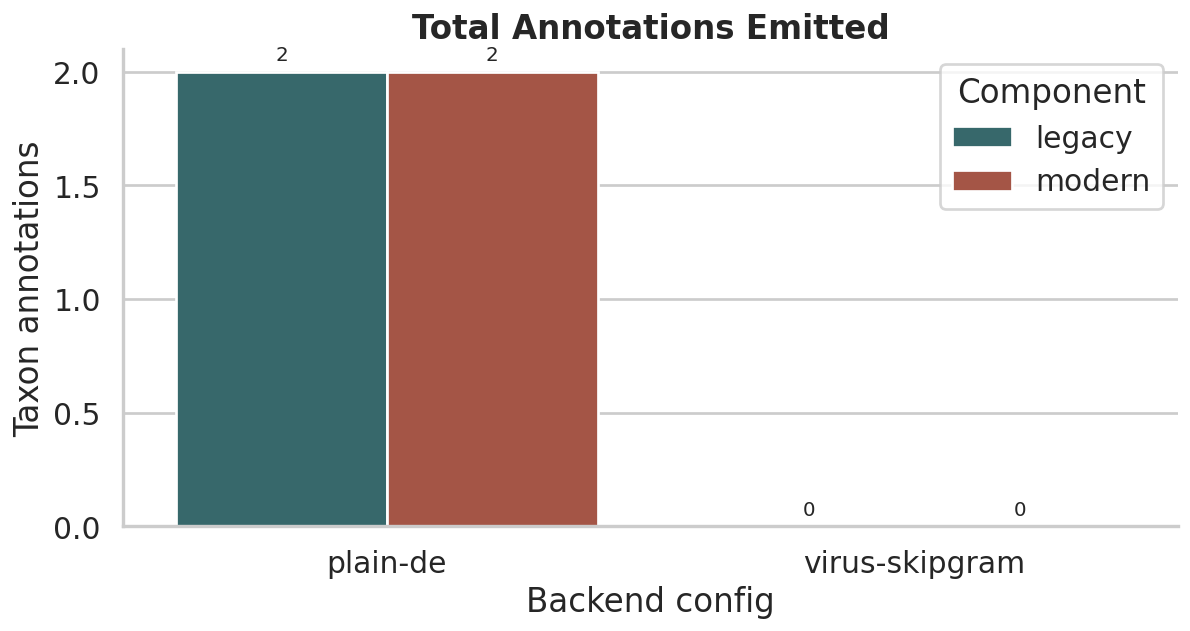

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
count_df = rows_df.groupby(["config", "component"], as_index=False)["annotation_count"].sum()
sns.barplot(
    data=count_df,
    x="config",
    y="annotation_count",
    hue="component",
    palette={"legacy": "#2f6f73", "modern": "#b44a36"},
    ax=ax,
)
ax.set_title("Total Annotations Emitted")
ax.set_xlabel("Backend config")
ax.set_ylabel("Taxon annotations")
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=11)
ax.legend(title="Component")
sns.despine()
plt.tight_layout()

## Telemetry Event Breakdown

This shows that the evaluation is not just timing with `time.perf_counter`; it captures the DUUI-Py telemetry surface used by annotators and the request recorder.

config,plain-de,virus-skipgram
type,,
log,28,28
metric,672,672
span,14,14
summary,14,14


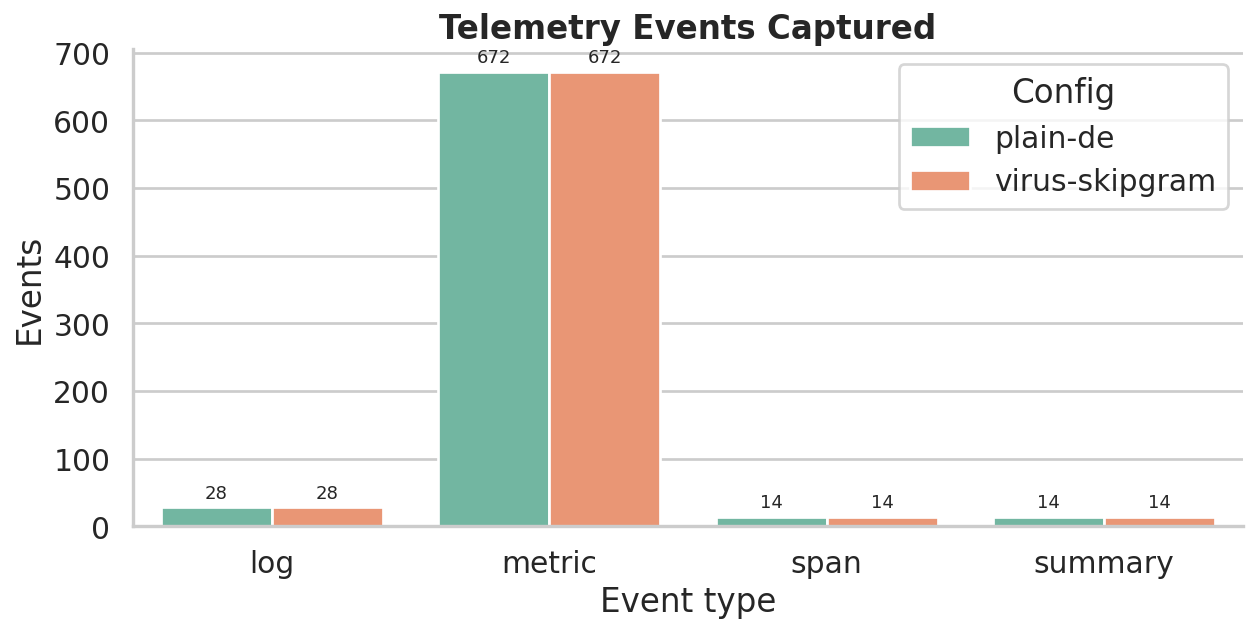

In [6]:
event_counts = events_df.groupby(["config", "type"]).size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(10, 5.2))
sns.barplot(data=event_counts, x="type", y="count", hue="config", palette="Set2", ax=ax)
ax.set_title("Telemetry Events Captured")
ax.set_xlabel("Event type")
ax.set_ylabel("Events")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
ax.legend(title="Config")
sns.despine()
plt.tight_layout()
event_counts.pivot(index="type", columns="config", values="count").fillna(0).astype(int)

## Top Metrics

Most frequent metric names emitted during the two paired config runs.

,metric,count
0,duui.request.duration,84
1,duui.request.duration.histogram,84
2,duui.request.throughput,84
3,duui.request.count,84
4,process.cpu.utilization,56
5,process.cpu.time.user,56
6,process.cpu.time.system,56
7,process.context_switches.voluntary,56
8,process.context_switches.involuntary,56
9,system.cpu.utilization,56


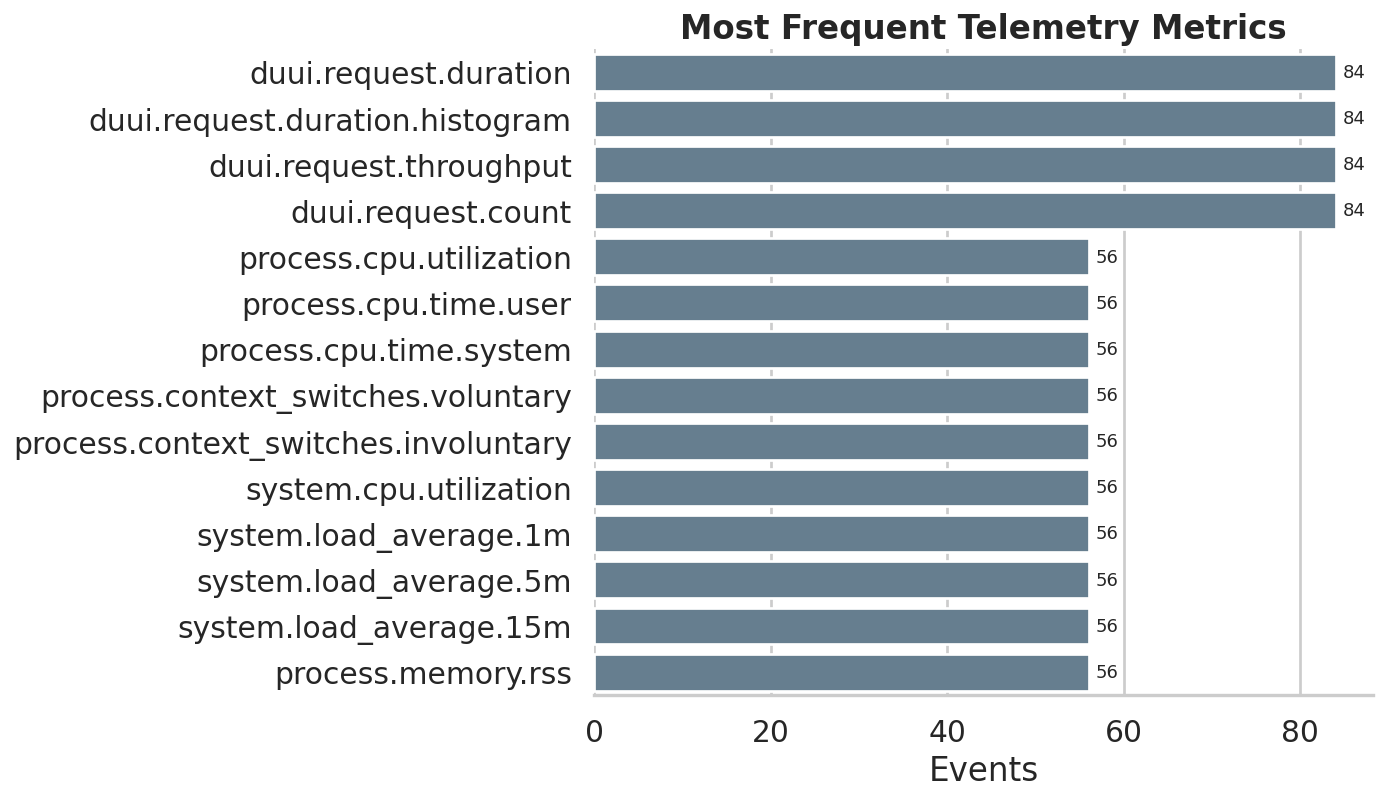

In [7]:
metrics_df = events_df[events_df["type"] == "metric"].copy()
top_metrics = metrics_df["name"].value_counts().head(14).reset_index()
top_metrics.columns = ["metric", "count"]

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(data=top_metrics, y="metric", x="count", color="#5f7f96", ax=ax)
ax.set_title("Most Frequent Telemetry Metrics")
ax.set_xlabel("Events")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10)
sns.despine(left=True)
plt.tight_layout()
top_metrics

## Sample Matched Annotations

A compact view of the actual normalized annotations from `plain-de`. Legacy and modern agree exactly.

In [8]:
sample_rows = []
for key, anns in config_runs["plain-de"]["sample_annotations"].items():
    component, doc_id = key.split("::", 1)
    for ann in anns:
        sample_rows.append({"component": component, "doc_id": doc_id, **ann})

sample_df = pd.DataFrame(sample_rows)
sample_df

,component,doc_id,begin,end,covered,value,identifier
0,legacy,3713534-chunk-1,1889,1899,Steinbrech,Steinbrech,https://www.biofid.de/bio-ontologies/gbif/2987833
1,modern,3713534-chunk-1,1889,1899,Steinbrech,Steinbrech,https://www.biofid.de/bio-ontologies/gbif/2987833


## Interpretation

- The migration looks functionally equivalent for this small Gazetteer pair and two backend configs.
- Modern MsgPack/Lua is not materially slower here; both paths are around 3 ms per warm local request.
- The telemetry layer is usable for a proper evaluation report: request duration, throughput, histograms, spans, summaries, CPU, and memory metrics are all present.
- This is not a final corpus-scale benchmark. It is a clean demonstration scaffold that can be expanded to the full BioFID config and more documents once backend loading/runtime constraints are handled.